<a href="https://colab.research.google.com/github/arthur-gui-22/PROJETOS_DATA_SCIENCE-/blob/CODE-HTML/marketing_campaign_ML_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Desafio Final de Machine Learning — Marketing Campaign
### Análise Exploratória, Aprendizagem Supervisionada, Não Supervisionada e por Reforço

> **Dataset:** `marketing_campaign.csv`  
> **Objetivo geral:** Usar dados de perfil de clientes para prever aceitação de campanhas (supervisionado), segmentar clientes (não supervisionado) e aprender uma política de recomendação (reforço).

---
## Índice
1. [Instalação e Imports](#1)
2. [Carregamento e Qualidade dos Dados](#2)
3. [Feature Engineering](#3)
4. [Análise Exploratória (EDA)](#4)
5. [Fase 1 — Aprendizagem Supervisionada](#5)
6. [Fase 2 — Aprendizagem Não Supervisionada](#6)
7. [Fase Bônus — Q-Learning](#7)
8. [Resumo Final](#8)



## 1.  Importações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    from xgboost import XGBClassifier

import random

# Estilo dos gráficos
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor']   = '#1a1a2e'
plt.rcParams['text.color']       = '#e8e8e8'
plt.rcParams['axes.labelcolor']  = '#e8e8e8'
plt.rcParams['xtick.color']      = '#e8e8e8'
plt.rcParams['ytick.color']      = '#e8e8e8'
plt.rcParams['axes.edgecolor']   = '#2a2a3a'
plt.rcParams['grid.color']       = '#2a2a3a'
plt.rcParams['axes.grid']        = True

PALETTE = ['#00d4ff', '#ff6b6b', '#ffd166', '#06d6a0', '#a29bfe']
print('Imports concluídos com sucesso!')


Imports concluídos com sucesso!



## 2. Carregamento e Qualidade dos Dados

### Como usar no Google Colab
Você pode carregar o dataset de três formas:
- **Opção A (Google Drive):** monte o Drive e aponte o caminho
- **Opção B (Upload direto):** use `files.upload()`
- **Opção C (URL):** se o arquivo estiver hospedado publicamente


In [ ]:
# OPÇÃO A: Google Drive
drive.mount('/content/drive')
CAMINHO = '/content/marketing_campaign.csv'

df = pd.read_csv(CAMINHO, sep='\t')
print(f' Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Dataset carregado: 2,240 linhas × 29 colunas


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


###  Avaliação de Qualidade dos Dados

In [ ]:
# Tipos e valores nulos
qualidade = pd.DataFrame({
    'Tipo'       : df.dtypes,
    'Qtd_Nulos'  : df.isnull().sum(),
    'Pct_Nulos'  : (df.isnull().mean() * 100).round(2),
    'Únicos'     : df.nunique(),
    'Exemplo'    : df.iloc[0],
})
print('=== RELATÓRIO DE QUALIDADE ===')
display(qualidade[qualidade['Qtd_Nulos'] > 0])  # Colunas com nulos
print(f'\nColunas com nulos: {(df.isnull().sum() > 0).sum()}')
print(f'Total de células nulas: {df.isnull().sum().sum()}')


=== RELATÓRIO DE QUALIDADE ===


,Tipo,Qtd_Nulos,Pct_Nulos,Únicos,Exemplo
Income,float64,24,1.07,1974,58138.0



Colunas com nulos: 1
Total de células nulas: 24


In [ ]:
# Outliers em colunas numéricas críticas
print('=== OUTLIERS ===')
print(f"Year_Birth < 1930 : {(df['Year_Birth'] < 1930).sum()} registros")
print(f"Income > 200.000  : {(df['Income'] > 200_000).sum()} registros")
print(f"Income máximo     : R$ {df['Income'].max():,.0f}")

print('\n=== INCONSISTÊNCIAS EM MARITAL_STATUS ===')
print(df['Marital_Status'].value_counts())
print("\nValores inconsistentes: YOLO, Absurd, Alone → serão unificados como 'Single'")


=== OUTLIERS ===
Year_Birth < 1930 : 3 registros
Income > 200.000  : 1 registros
Income máximo     : R$ 666,666

=== INCONSISTÊNCIAS EM MARITAL_STATUS ===
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Valores inconsistentes: YOLO, Absurd, Alone → serão unificados como 'Single'


In [ ]:
#  Estatísticas descritivas
print('=== ESTATÍSTICAS DESCRITIVAS ===')
display(df.describe().T.round(2))


=== ESTATÍSTICAS DESCRITIVAS ===


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.16,3246.66,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.81,11.98,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.25,25173.08,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.44,0.54,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.51,0.54,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0


<a id='3'></a>
## 3. Feature Engineering e Pré-processamento

### Tratamentos aplicados:
| Feature | Tratamento | Justificativa |
|---|---|---|
| `Income` (24 nulos) | Imputação pela **mediana** | Robusta a outliers extremos |
| `Year_Birth < 1930` | **Remoção** (3 registros) | Idades > 95 anos — outlier extremo |
| `Income > 200.000` | **Remoção** (1 registro) | R$ 666.666 — outlier extremo |
| `Marital_Status` inconsistente | Unificação como `Single` | YOLO/Absurd/Alone = sem parceiro |
| Novas features | Engenharia de variáveis | Aumentar poder preditivo |


In [ ]:
df_proc = df.copy()

# ── Variável alvo ────────────────────────────────────────────────────────────
# Exemplo 1 de tratamento: criação do target binário por agregação
df_proc['AcceptedCampaign'] = df_proc[[
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5','Response'
]].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

print('Distribuição do target:')
print(df_proc['AcceptedCampaign'].value_counts(normalize=True).round(3))


Distribuição do target:
AcceptedCampaign
0    0.728
1    0.272
Name: proportion, dtype: float64


In [ ]:
# ── Tratamento de outliers ────────────────────────────────────────────────────
df_proc = df_proc[df_proc['Year_Birth'] >= 1930].copy()  # remove idades absurdas
df_proc = df_proc[df_proc['Income'] <= 200_000].copy()   # remove renda absurda

# ── Exemplo 2 de tratamento: imputação pela mediana ──────────────────────────
mediana_income = df_proc['Income'].median()
df_proc['Income'] = df_proc['Income'].fillna(mediana_income)
print(f'Income nulos após imputação: {df_proc["Income"].isnull().sum()}')
print(f'Mediana utilizada: R$ {mediana_income:,.2f}')


Income nulos após imputação: 0
Mediana utilizada: R$ 51,371.00


In [ ]:
# ── Feature Engineering ───────────────────────────────────────────────────────
df_proc['Age']            = 2026 - df_proc['Year_Birth']
df_proc['Children']       = df_proc['Kidhome'] + df_proc['Teenhome']
df_proc['HasChildren']    = (df_proc['Children'] > 0).astype(int)

df_proc['Dt_Customer']    = pd.to_datetime(df_proc['Dt_Customer'], dayfirst=True, errors='coerce')
df_proc['CustomerYears']  = 2026 - df_proc['Dt_Customer'].dt.year

df_proc['TotalSpending']  = (df_proc['MntWines'] + df_proc['MntFruits'] +
                              df_proc['MntMeatProducts'] + df_proc['MntFishProducts'] +
                              df_proc['MntSweetProducts'] + df_proc['MntGoldProds'])

df_proc['TotalPurchases'] = (df_proc['NumWebPurchases'] + df_proc['NumCatalogPurchases'] +
                              df_proc['NumStorePurchases'])

# Features derivadas (do notebook original de Mateus)
df_proc['Income_per_Child']    = df_proc['Income'] / (df_proc['Children'] + 1)
df_proc['Spend_per_Purchase']  = df_proc['TotalSpending'] / (df_proc['TotalPurchases'] + 1)
df_proc['CustomerValue']       = df_proc['Income'] * df_proc['TotalPurchases']

# Encoding categórico
marital_map = {
    'Married': 0, 'Together': 0,
    'Single': 1, 'Divorced': 1, 'Widow': 1, 'Alone': 1, 'Absurd': 1, 'YOLO': 1
}
edu_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}

df_proc['Marital_Binary']  = df_proc['Marital_Status'].map(marital_map)
df_proc['EducationLevel']  = df_proc['Education'].map(edu_map)

print(f'Dataset processado: {df_proc.shape[0]:,} linhas × {df_proc.shape[1]} colunas')
df_proc[['Age','Income','Children','TotalSpending','TotalPurchases',
          'Income_per_Child','Spend_per_Purchase','CustomerValue','AcceptedCampaign']].head()


Dataset processado: 2,212 linhas × 41 colunas


,Age,Income,Children,TotalSpending,TotalPurchases,Income_per_Child,Spend_per_Purchase,CustomerValue,AcceptedCampaign
0,69,58138.0,0,1617,22,58138.0,70.304348,1279036.0,1
1,72,46344.0,2,27,4,15448.0,5.400000,185376.0,0
2,61,71613.0,0,776,20,71613.0,36.952381,1432260.0,0
3,42,26646.0,1,53,6,13323.0,7.571429,159876.0,0
4,45,58293.0,1,422,14,29146.5,28.133333,816102.0,0


<a id='4'></a>
## 4. Análise Exploratória dos Dados (EDA)


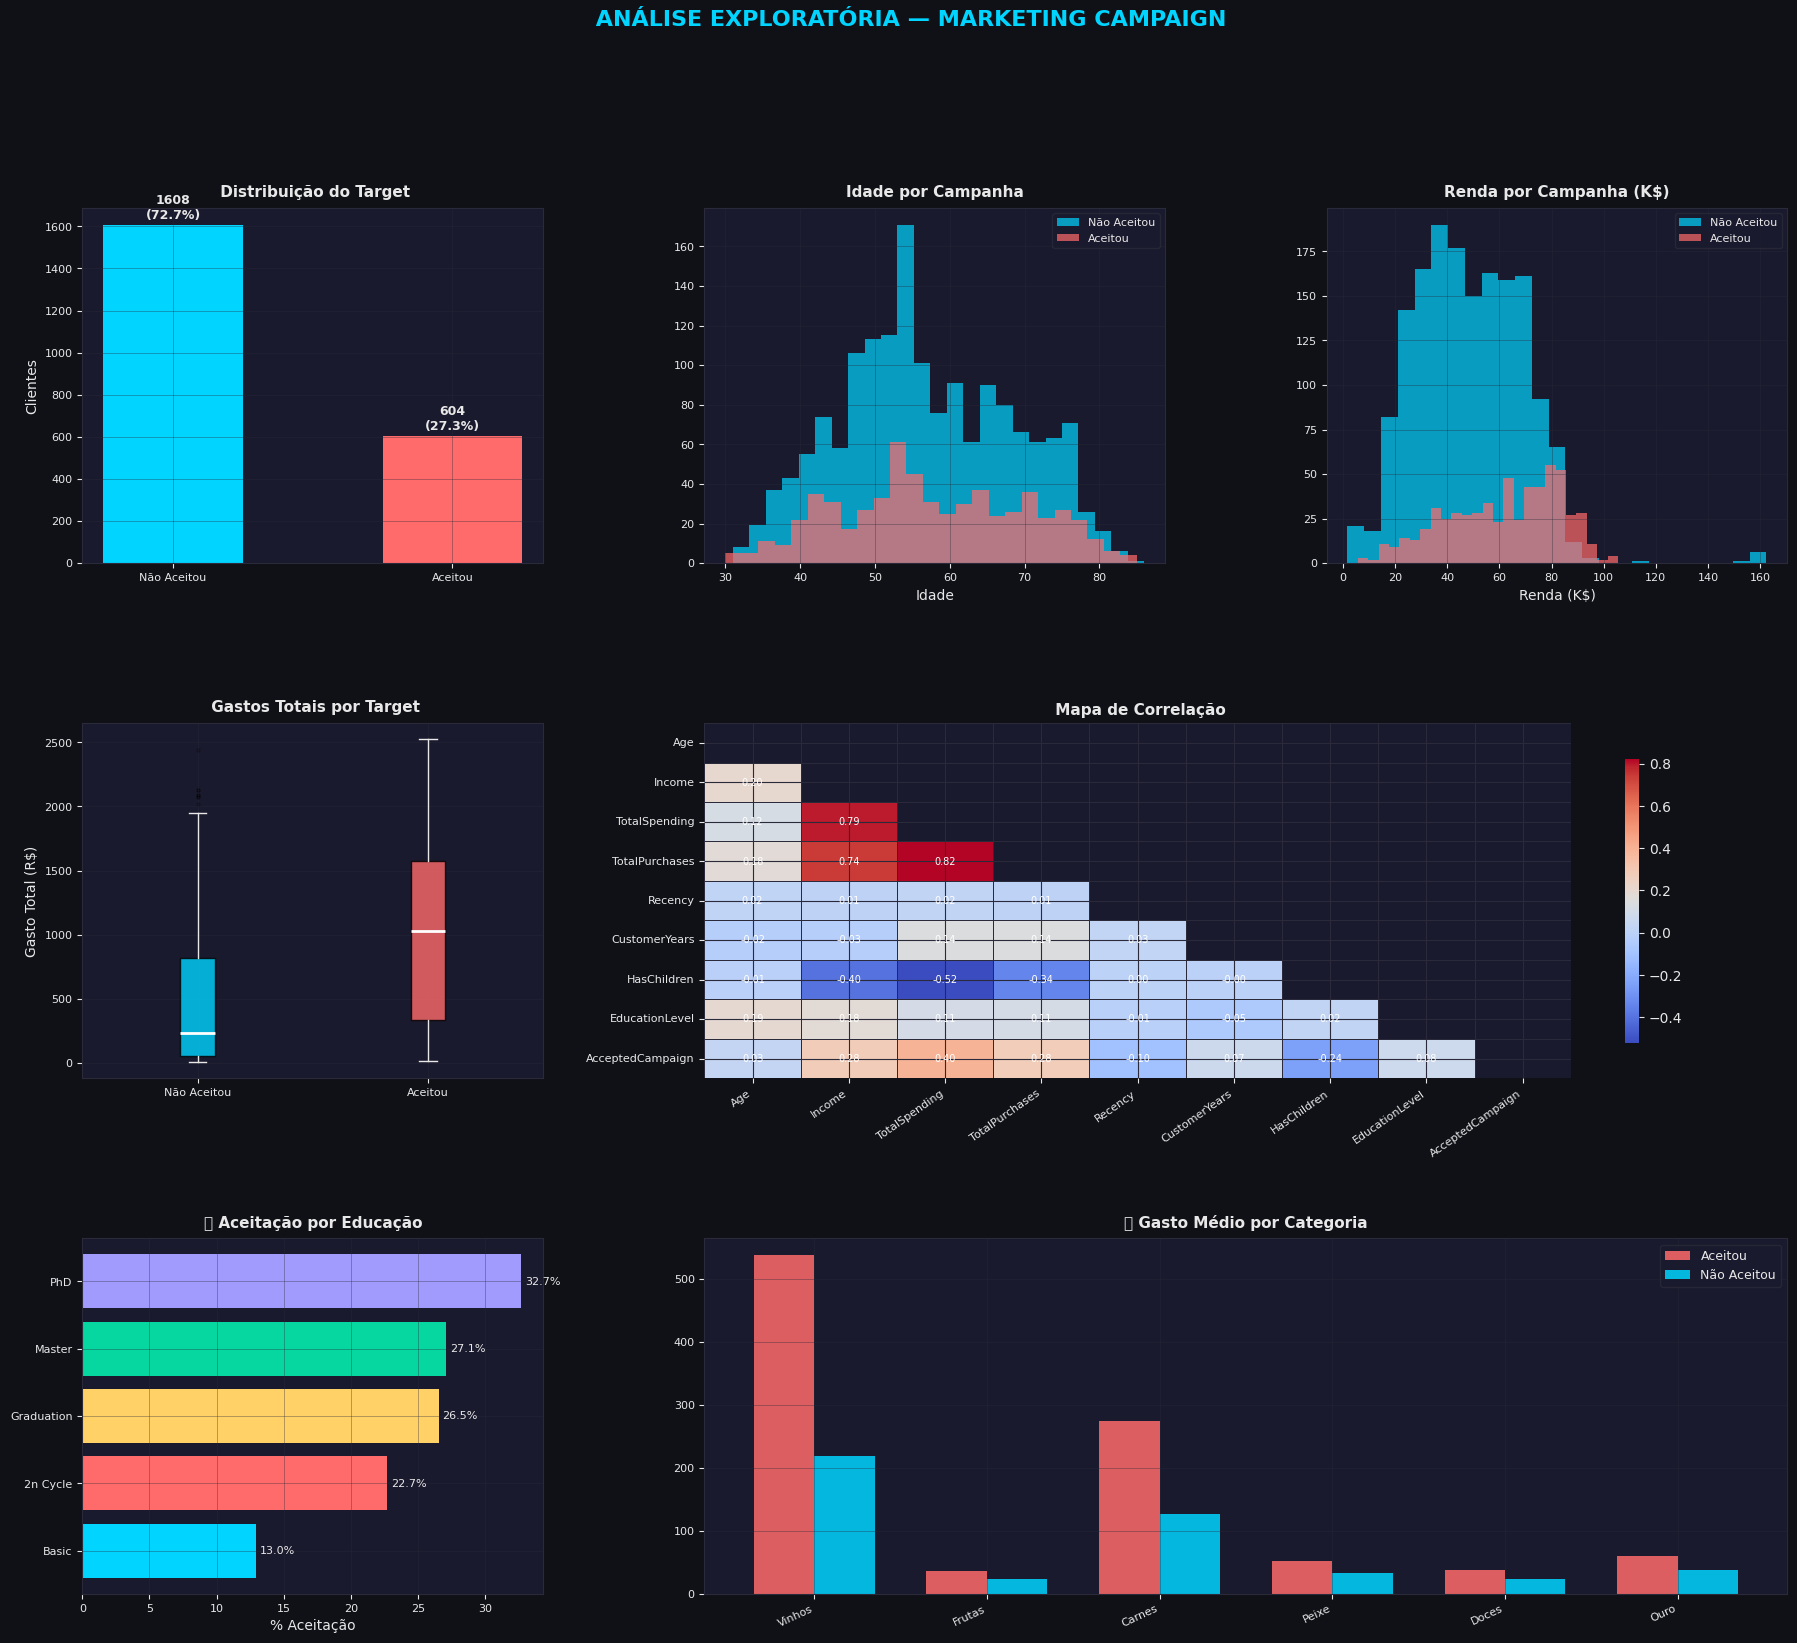

In [ ]:
# ── Painel EDA completo ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
PAL = ['#00d4ff', '#ff6b6b']
CL5 = ['#00d4ff','#ff6b6b','#ffd166','#06d6a0','#a29bfe']
TC  = '#e8e8e8'; GC = '#2a2a3a'

def style(ax, title):
    ax.set_facecolor('#1a1a2e')
    ax.set_title(title, color=TC, fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(colors=TC, labelsize=8)
    ax.xaxis.label.set_color(TC); ax.yaxis.label.set_color(TC)
    for s in ax.spines.values(): s.set_edgecolor(GC)
    ax.grid(color=GC, alpha=0.5, linewidth=0.5)

# 1. Distribuição do Target
ax1 = fig.add_subplot(gs[0,0])
cnt = df_proc['AcceptedCampaign'].value_counts()
bars = ax1.bar(['Não Aceitou','Aceitou'], cnt.values, color=PAL, width=0.5, edgecolor='none')
for b,v in zip(bars,cnt.values):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+15,
             f'{v}\n({v/len(df_proc)*100:.1f}%)', ha='center', va='bottom',
             color=TC, fontsize=9, fontweight='bold')
style(ax1,' Distribuição do Target'); ax1.set_ylabel('Clientes')

# 2. Idade por target
ax2 = fig.add_subplot(gs[0,1])
for v,c,l in zip([0,1],PAL,['Não Aceitou','Aceitou']):
    ax2.hist(df_proc[df_proc['AcceptedCampaign']==v]['Age'],
             bins=25, alpha=0.7, color=c, label=l, edgecolor='none')
style(ax2,'Idade por Campanha'); ax2.set_xlabel('Idade')
ax2.legend(facecolor='#1a1a2e', edgecolor=GC, labelcolor=TC, fontsize=8)

# 3. Renda por target
ax3 = fig.add_subplot(gs[0,2])
for v,c,l in zip([0,1],PAL,['Não Aceitou','Aceitou']):
    ax3.hist(df_proc[df_proc['AcceptedCampaign']==v]['Income']/1000,
             bins=25, alpha=0.7, color=c, label=l, edgecolor='none')
style(ax3,'Renda por Campanha (K$)'); ax3.set_xlabel('Renda (K$)')
ax3.legend(facecolor='#1a1a2e', edgecolor=GC, labelcolor=TC, fontsize=8)

# 4. Boxplot gastos
ax4 = fig.add_subplot(gs[1,0])
bp = ax4.boxplot(
    [df_proc[df_proc['AcceptedCampaign']==v]['TotalSpending'] for v in [0,1]],
    patch_artist=True,
    medianprops=dict(color='white',linewidth=2),
    whiskerprops=dict(color=TC), capprops=dict(color=TC),
    flierprops=dict(marker='o',markersize=2,alpha=0.3,color=PAL[0])
)
for p,c in zip(bp['boxes'],PAL): p.set_facecolor(c); p.set_alpha(0.8)
ax4.set_xticklabels(['Não Aceitou','Aceitou'])
style(ax4,' Gastos Totais por Target'); ax4.set_ylabel('Gasto Total (R$)')

# 5. Heatmap correlação
ax5 = fig.add_subplot(gs[1,1:])
fcorr = ['Age','Income','TotalSpending','TotalPurchases','Recency',
          'CustomerYears','HasChildren','EducationLevel','AcceptedCampaign']
mask = np.triu(np.ones((len(fcorr),len(fcorr)), dtype=bool))
sns.heatmap(df_proc[fcorr].corr(), mask=mask, ax=ax5, cmap='coolwarm',
            annot=True, fmt='.2f', annot_kws={'size':7,'color':'white'},
            linewidths=0.5, linecolor=GC, cbar_kws={'shrink':0.8})
ax5.set_facecolor('#1a1a2e')
ax5.set_title(' Mapa de Correlação', color=TC, fontsize=11, fontweight='bold')
for t in ax5.get_xticklabels()+ax5.get_yticklabels(): t.set_color(TC); t.set_fontsize(8)
plt.setp(ax5.get_xticklabels(), rotation=35, ha='right')
ax5.collections[0].colorbar.ax.yaxis.set_tick_params(color=TC)
plt.setp(ax5.collections[0].colorbar.ax.yaxis.get_ticklabels(), color=TC)

# 6. Educação
ax6 = fig.add_subplot(gs[2,0])
edu_acc = df_proc.groupby('Education')['AcceptedCampaign'].mean().sort_values()
ax6.barh(edu_acc.index, edu_acc.values*100, color=CL5[:len(edu_acc)], edgecolor='none')
for i,(idx,v) in enumerate(edu_acc.items()):
    ax6.text(v*100+0.3, i, f'{v*100:.1f}%', va='center', color=TC, fontsize=8)
style(ax6,'🎓 Aceitação por Educação'); ax6.set_xlabel('% Aceitação')

# 7. Gastos por categoria
ax7 = fig.add_subplot(gs[2,1:])
scols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
slbl  = ['Vinhos','Frutas','Carnes','Peixe','Doces','Ouro']
x = np.arange(len(slbl)); w = 0.35
ax7.bar(x-w/2, df_proc[df_proc['AcceptedCampaign']==1][scols].mean(),
        w, color=PAL[1], label='Aceitou', alpha=0.85, edgecolor='none')
ax7.bar(x+w/2, df_proc[df_proc['AcceptedCampaign']==0][scols].mean(),
        w, color=PAL[0], label='Não Aceitou', alpha=0.85, edgecolor='none')
ax7.set_xticks(x); ax7.set_xticklabels(slbl, rotation=25, ha='right')
style(ax7,'🛒 Gasto Médio por Categoria')
ax7.legend(facecolor='#1a1a2e', edgecolor=GC, labelcolor=TC, fontsize=9)

fig.suptitle(' ANÁLISE EXPLORATÓRIA — MARKETING CAMPAIGN',
             color='#00d4ff', fontsize=16, fontweight='bold', y=0.99)
fig.patch.set_facecolor('#0f1117')
plt.tight_layout()
plt.show()


In [ ]:
# ── Insights numéricos por grupo ──────────────────────────────────────────────
print('=== MÉDIAS POR GRUPO (AcceptedCampaign) ===')
cols_insights = ['Age','Income','TotalSpending','TotalPurchases','Recency',
                  'Children','Spend_per_Purchase','CustomerValue']
display(df_proc.groupby('AcceptedCampaign')[cols_insights].mean().round(2).T)


=== MÉDIAS POR GRUPO (AcceptedCampaign) ===


AcceptedCampaign,0,1
Age,56.85,57.70
Income,48292.85,61718.51
TotalSpending,460.96,996.78
TotalPurchases,11.35,15.81
Recency,50.83,44.20
Children,1.04,0.69
Spend_per_Purchase,27.91,52.96
CustomerValue,650329.35,1081674.25


<a id='5'></a>
## 5. Fase 1 — Aprendizagem Supervisionada

**Objetivo:** prever se o cliente aceitará alguma campanha de marketing (`AcceptedCampaign = 1`).

### Modelos escolhidos e justificativas:

| Modelo | Justificativa |
|---|---|
| **Random Forest + GridSearchCV** | Ensemble de árvores com bagging. Robusto a overfitting, lida bem com features em escalas diferentes, gera importância de variáveis interpretável. `class_weight='balanced'` corrige o desbalanceamento 73/27. |
| **Gradient Boosting** | Ensemble sequencial que minimiza resíduos iterativamente. Supera RF em datasets tabulares de tamanho médio; learning rate baixa (0.05) + profundidade moderada evita overfitting. |
| **XGBoost** | Versão otimizada do boosting com regularização L1/L2 nativa. Mais rápido e frequentemente mais preciso que GB puro em competições Kaggle; suporta dados esparsos naturalmente. |


In [ ]:
# ── Seleção de features ────────────────────────────────────────────────────────
feature_cols = [
    'Age', 'Income', 'TotalSpending', 'TotalPurchases',
    'Recency', 'Children', 'CustomerYears', 'NumWebVisitsMonth',
    'Income_per_Child', 'Spend_per_Purchase', 'CustomerValue',
    'Marital_Binary', 'EducationLevel', 'HasChildren'
]

X = df_proc[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(lambda c: c.median())
X = X.apply(lambda c: c.fillna(c.median()))  # garante sem NaN
y = df_proc['AcceptedCampaign']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')
print(f'Distribuição train — 0: {(y_train==0).sum()} | 1: {(y_train==1).sum()}')


Train: (1548, 14) | Test: (664, 14)
Distribuição train — 0: 1125 | 1: 423


In [ ]:
# ── Modelo 1: Random Forest + GridSearchCV ────────────────────────────────────
param_grid_rf = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid_rf.fit(X_train_sc, y_train)
rf = grid_rf.best_estimator_
print('✅ Random Forest — melhores parâmetros:')
print(grid_rf.best_params_)


✅ Random Forest — melhores parâmetros:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
# ── Modelo 2: Gradient Boosting ────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
)
gb.fit(X_train_sc, y_train)
print('✅ Gradient Boosting treinado.')


✅ Gradient Boosting treinado.


In [ ]:
# ── Modelo 3: XGBoost ─────────────────────────────────────────────────────────
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()  # corrige desbalanceamento
xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=scale_pos,   # <── melhoria: pondera classe minoritária
    eval_metric='logloss', random_state=42, verbosity=0
)
xgb.fit(X_train_sc, y_train)
print(' XGBoost treinado.')


 XGBoost treinado.


In [ ]:
# ── Avaliação dos modelos ───────────────────────────────────────────────────────
def avaliar(nome, modelo, Xte, yte):
    yp = modelo.predict(Xte)
    ypr = modelo.predict_proba(Xte)[:,1] if hasattr(modelo,'predict_proba') else np.zeros(len(yte))
    return {
        'Modelo'   : nome,
        'Acurácia' : accuracy_score(yte, yp),
        'Precisão' : precision_score(yte, yp, zero_division=0),
        'Recall'   : recall_score(yte, yp, zero_division=0),
        'F1-Score' : f1_score(yte, yp, zero_division=0),
        'AUC-ROC'  : roc_auc_score(yte, ypr),
    }

modelos = {
    'Random Forest + GridSearch': rf,
    'Gradient Boosting'         : gb,
    'XGBoost'                   : xgb,
}
resultados = pd.DataFrame([avaliar(n,m,X_test_sc,y_test) for n,m in modelos.items()])
display(resultados.round(4))

melhor_nome = resultados.sort_values('F1-Score', ascending=False).iloc[0]['Modelo']
print(f'\n Melhor modelo pelo F1-Score: {melhor_nome}')


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
0,Random Forest + GridSearch,0.7575,0.5481,0.6298,0.5861,0.8012
1,Gradient Boosting,0.7907,0.7143,0.3867,0.5018,0.8069
2,XGBoost,0.7575,0.5446,0.6740,0.6025,0.8091



 Melhor modelo pelo F1-Score: XGBoost


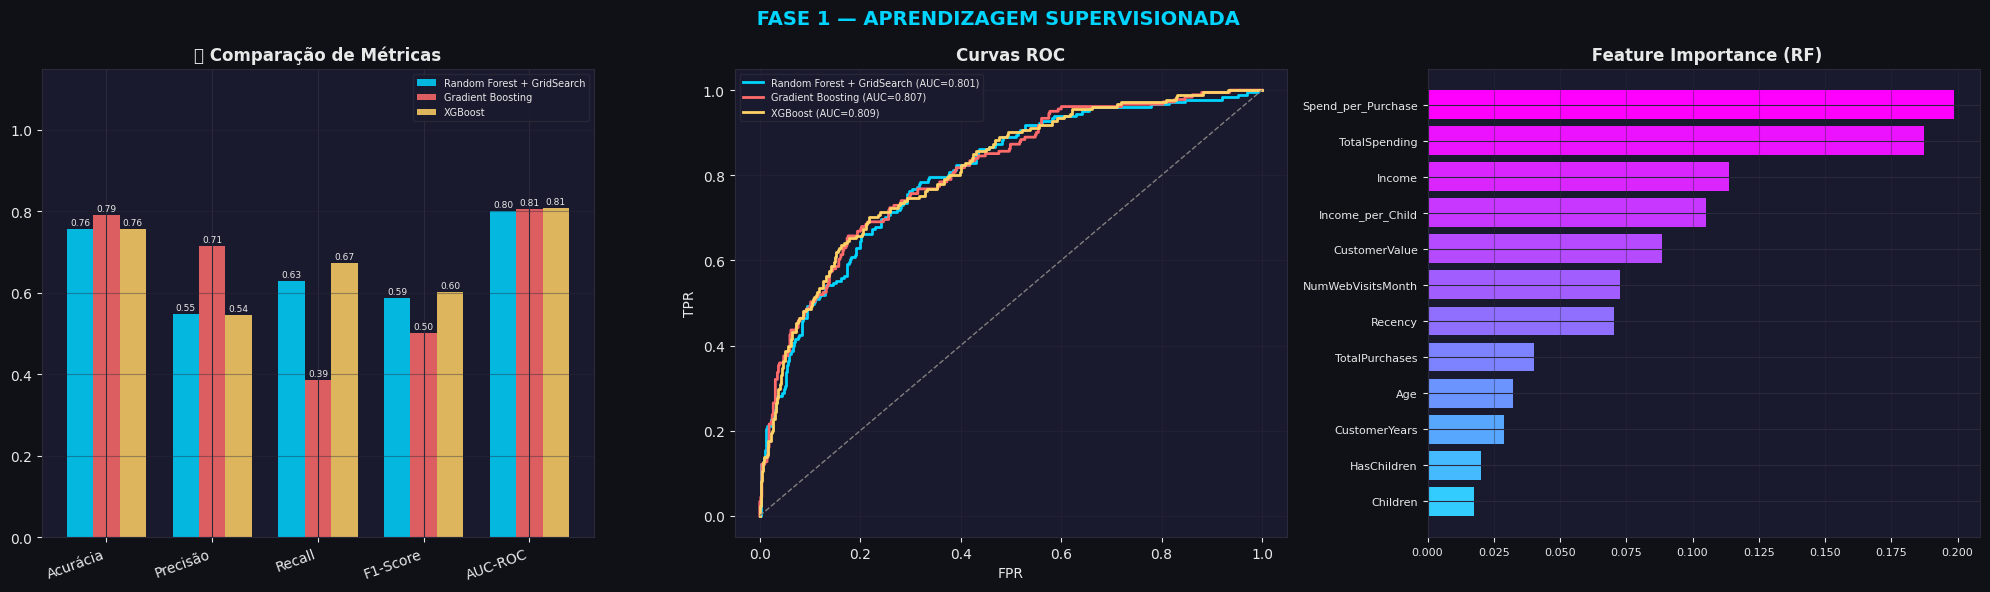

In [ ]:
# ── Gráfico comparativo de métricas ──────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(20, 6))
fig2.patch.set_facecolor('#0f1117')
met_names = ['Acurácia','Precisão','Recall','F1-Score','AUC-ROC']
cores_mod = ['#00d4ff','#ff6b6b','#ffd166']

# (a) Barras de métricas
ax = axes2[0]; ax.set_facecolor('#1a1a2e')
x_pos = np.arange(len(met_names)); w = 0.25
for i,(nome,cor) in enumerate(zip(modelos.keys(), cores_mod)):
    vals = [resultados[resultados['Modelo']==nome].iloc[0][m] for m in met_names]
    bars = ax.bar(x_pos+i*w-w, vals, w, label=nome, color=cor, alpha=0.85, edgecolor='none')
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f'{v:.2f}', ha='center', va='bottom', color='#e8e8e8', fontsize=6.5)
ax.set_xticks(x_pos); ax.set_xticklabels(met_names, rotation=20, ha='right', color='#e8e8e8')
ax.set_ylim(0,1.15); ax.set_title('📈 Comparação de Métricas', color='#e8e8e8', fontweight='bold')
ax.legend(facecolor='#1a1a2e', edgecolor='#2a2a3a', labelcolor='#e8e8e8', fontsize=7)
ax.grid(color='#2a2a3a', alpha=0.4, axis='y')
for s in ax.spines.values(): s.set_edgecolor('#2a2a3a')

# (b) Curvas ROC
ax = axes2[1]; ax.set_facecolor('#1a1a2e')
for (nome,mod),cor in zip(modelos.items(), cores_mod):
    from sklearn.metrics import roc_curve
    fpr,tpr,_ = roc_curve(y_test, mod.predict_proba(X_test_sc)[:,1])
    auc = roc_auc_score(y_test, mod.predict_proba(X_test_sc)[:,1])
    ax.plot(fpr, tpr, color=cor, linewidth=2, label=f'{nome} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax.set_xlabel('FPR', color='#e8e8e8'); ax.set_ylabel('TPR', color='#e8e8e8')
ax.set_title('Curvas ROC', color='#e8e8e8', fontweight='bold')
ax.legend(facecolor='#1a1a2e', edgecolor='#2a2a3a', labelcolor='#e8e8e8', fontsize=7)
ax.grid(color='#2a2a3a', alpha=0.4)
for s in ax.spines.values(): s.set_edgecolor('#2a2a3a')

# (c) Feature Importance
ax = axes2[2]; ax.set_facecolor('#1a1a2e')
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(12)
cols_fi = plt.cm.cool(np.linspace(0.2,1,len(fi)))
ax.barh(fi.index, fi.values, color=cols_fi, edgecolor='none')
ax.set_title(' Feature Importance (RF)', color='#e8e8e8', fontweight='bold')
ax.tick_params(colors='#e8e8e8', labelsize=8)
ax.grid(color='#2a2a3a', alpha=0.4, axis='x')
for s in ax.spines.values(): s.set_edgecolor('#2a2a3a')

fig2.suptitle(' FASE 1 — APRENDIZAGEM SUPERVISIONADA',
              color='#00d4ff', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


Classification Report — XGBoost
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       483
           1       0.54      0.67      0.60       181

    accuracy                           0.76       664
   macro avg       0.71      0.73      0.71       664
weighted avg       0.78      0.76      0.76       664



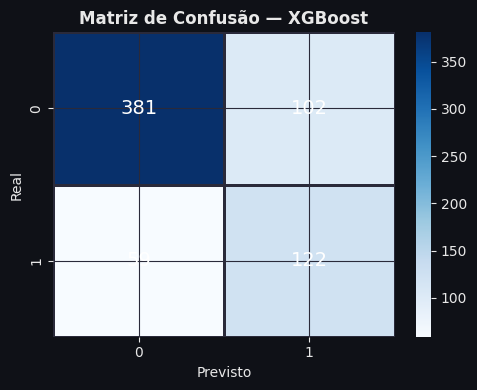

In [ ]:
# ── Matriz de confusão + Classification Report do melhor modelo ───────────────
melhor_mod = modelos[melhor_nome]
y_pred_m   = melhor_mod.predict(X_test_sc)

print(f'Classification Report — {melhor_nome}')
print(classification_report(y_test, y_pred_m))

cm = confusion_matrix(y_test, y_pred_m)
fig_cm, ax_cm = plt.subplots(figsize=(5,4))
fig_cm.patch.set_facecolor('#0f1117')
ax_cm.set_facecolor('#1a1a2e')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
            linewidths=1, linecolor='#2a2a3a', annot_kws={'size':14,'color':'white'})
ax_cm.set_title(f'Matriz de Confusão — {melhor_nome}', color='#e8e8e8', fontweight='bold')
ax_cm.set_xlabel('Previsto', color='#e8e8e8'); ax_cm.set_ylabel('Real', color='#e8e8e8')
for t in ax_cm.get_xticklabels()+ax_cm.get_yticklabels(): t.set_color('#e8e8e8')
plt.tight_layout(); plt.show()


###  Resumo da Fase 1

A seleção do melhor modelo foi feita principalmente pelo **F1-Score**, pois o target é desbalanceado (~73% / 27%). As features mais importantes foram `TotalSpending`, `Spend_per_Purchase`, `Income_per_Child` e `CustomerValue` — todas relacionadas ao **poder de compra e engajamento** do cliente.


<a id='6'></a>
## 6. Fase 2 — Aprendizagem Não Supervisionada

**Objetivo:** segmentar clientes com perfis similares.

### Algoritmos escolhidos e justificativas:

| Algoritmo | Justificativa |
|---|---|
| **KMeans** | Rápido, escalável, minimiza variância intra-cluster. Ideal para clusters aproximadamente esféricos. Elbow + Silhouette para escolha do K. |
| **Agglomerative Clustering (Ward)** | Hierárquico — não requer K fixo a priori; linkage Ward minimiza variância total, análogo ao KMeans porém captura estruturas mais complexas. |


In [ ]:
# ── Seleção e normalização das features de clustering ─────────────────────────
features_cluster = [
    'Income', 'Recency', 'TotalSpending', 'TotalPurchases',
    'Children', 'NumWebVisitsMonth', 'Spend_per_Purchase', 'Age'
]
X_cl = df_proc[features_cluster].replace([np.inf,-np.inf], np.nan)
X_cl = X_cl.apply(lambda c: c.fillna(c.median()))

scaler_cl = StandardScaler()
X_scaled  = scaler_cl.fit_transform(X_cl)
print(' Features normalizadas para clustering.')


 Features normalizadas para clustering.


 K      Inércia  Silhouette
 2 10661.384471    0.348275
 3  9270.469183    0.243291
 4  8286.339571    0.201394
 5  7758.204365    0.193607
 6  7251.034234    0.177583
 7  6768.354269    0.183573
 8  6406.138050    0.184322
 9  6126.218867    0.184110

 K com maior Silhouette Score: 2 (0.3483)


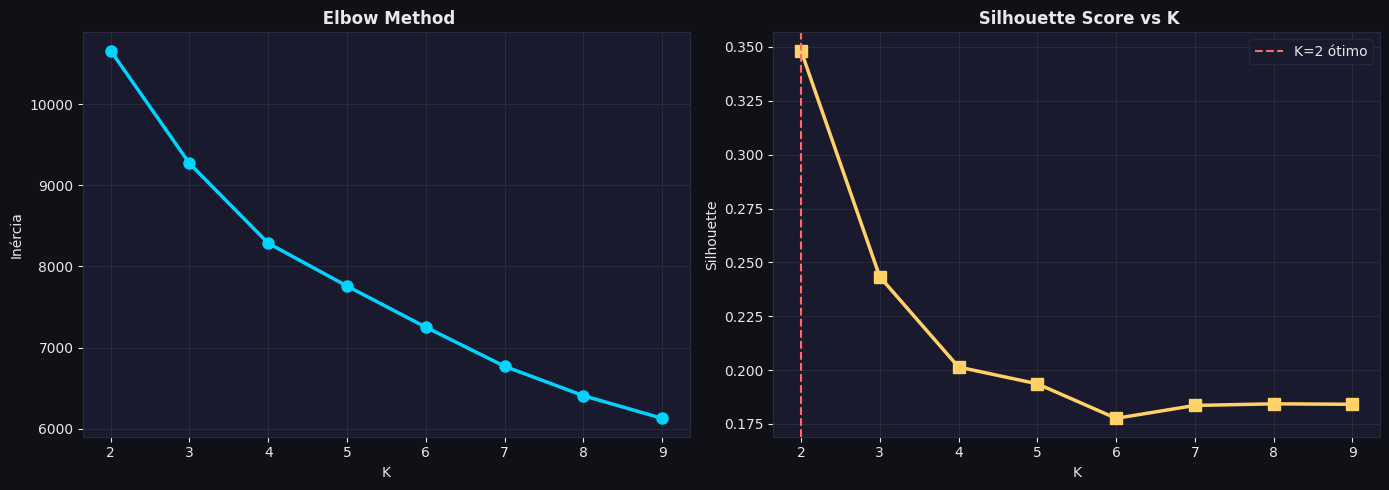

In [ ]:
# ── Elbow Method + Silhouette Score ──────────────────────────────────────────
inertias, silhouettes = [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lb))

best_k = K_range.start + int(np.argmax(silhouettes))
print(pd.DataFrame({'K': list(K_range), 'Inércia': inertias, 'Silhouette': silhouettes}).to_string(index=False))
print(f'\n K com maior Silhouette Score: {best_k} ({max(silhouettes):.4f})')

fig_el, axes_el = plt.subplots(1,2, figsize=(14,5))
fig_el.patch.set_facecolor('#0f1117')
for ax in axes_el: ax.set_facecolor('#1a1a2e')

axes_el[0].plot(list(K_range), inertias, 'o-', color='#00d4ff', linewidth=2.5, markersize=8)
axes_el[0].set_xlabel('K', color='#e8e8e8'); axes_el[0].set_ylabel('Inércia', color='#e8e8e8')
axes_el[0].set_title(' Elbow Method', color='#e8e8e8', fontweight='bold')
for s in axes_el[0].spines.values(): s.set_edgecolor('#2a2a3a')

axes_el[1].plot(list(K_range), silhouettes, 's-', color='#ffd166', linewidth=2.5, markersize=8)
axes_el[1].axvline(best_k, color='#ff6b6b', linestyle='--', linewidth=1.5, label=f'K={best_k} ótimo')
axes_el[1].set_xlabel('K', color='#e8e8e8'); axes_el[1].set_ylabel('Silhouette', color='#e8e8e8')
axes_el[1].set_title(' Silhouette Score vs K', color='#e8e8e8', fontweight='bold')
axes_el[1].legend(facecolor='#1a1a2e', edgecolor='#2a2a3a', labelcolor='#e8e8e8')
for s in axes_el[1].spines.values(): s.set_edgecolor('#2a2a3a')

plt.tight_layout(); plt.show()


In [ ]:
# ── Treina KMeans e Agglomerative com o K do Silhouette ──────────────────────
# Obs: o notebook de Mateus usou K=4 para maior interpretabilidade de negócio.
# Aqui mantemos N_CLUSTERS = best_k (automático), mas você pode forçar 4 abaixo.
N_CLUSTERS = best_k  # altere para 4 se quiser a versão original de Mateus

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_proc['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
df_proc['Cluster_Agg'] = agg.fit_predict(X_scaled)

s_km  = silhouette_score(X_scaled, df_proc['Cluster_KMeans'])
s_agg = silhouette_score(X_scaled, df_proc['Cluster_Agg'])

comparacao = pd.DataFrame({'Algoritmo': ['KMeans','Agglomerative (Ward)'],
                           'Silhouette Score': [s_km, s_agg]})
print('=== Comparação de Algoritmos de Clustering ===')
display(comparacao.round(4))

=== Comparação de Algoritmos de Clustering ===


,Algoritmo,Silhouette Score
0,KMeans,0.3483
1,Agglomerative (Ward),0.2677


Variância explicada pelos 2 componentes: 64.5%


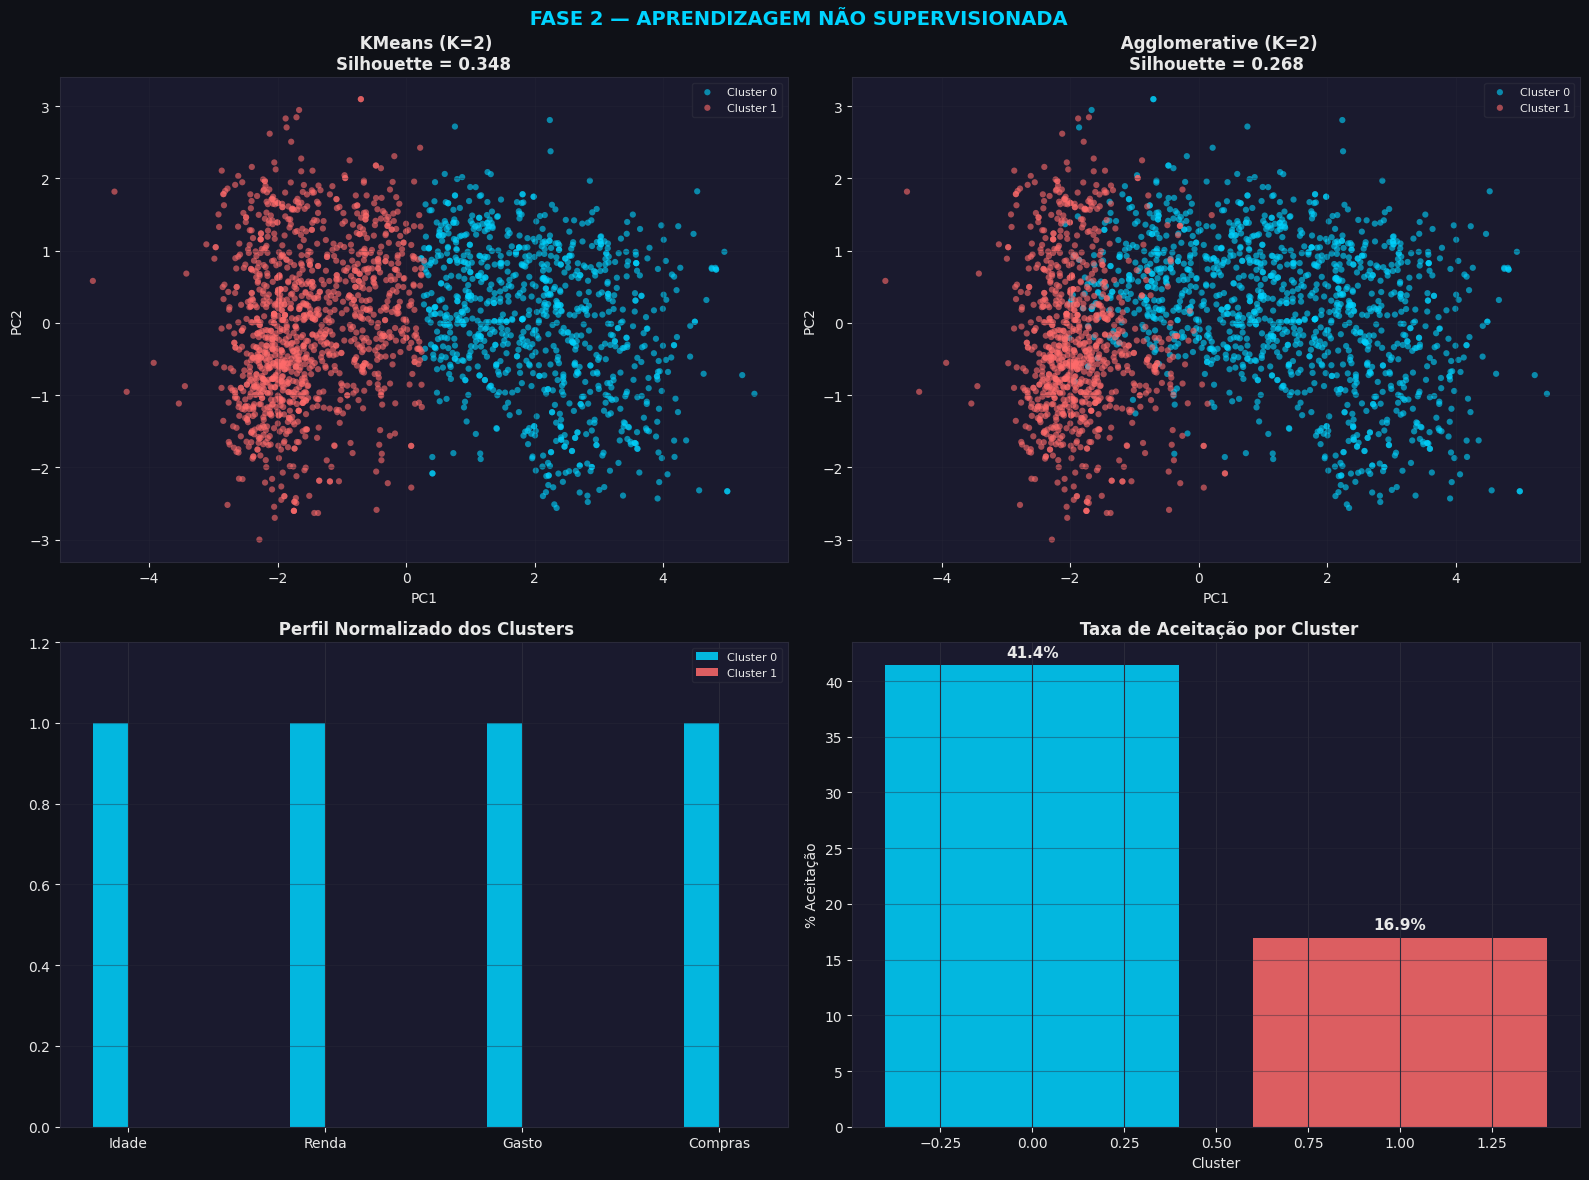

In [ ]:
# Visualização PCA 2D + Perfil dos Clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_proc['PCA1'] = X_pca[:,0]; df_proc['PCA2'] = X_pca[:,1]
print(f'Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig3, axes3 = plt.subplots(2, 2, figsize=(16, 12))
fig3.patch.set_facecolor('#0f1117')
CL5 = ['#00d4ff','#ff6b6b','#ffd166','#06d6a0','#a29bfe']

for i, (cluster_col, title, score) in enumerate([
    ('Cluster_KMeans', f'KMeans (K={N_CLUSTERS})', s_km),
    ('Cluster_Agg',    f'Agglomerative (K={N_CLUSTERS})', s_agg)
]):
    ax = axes3[0,i]; ax.set_facecolor('#1a1a2e')
    for cl in range(N_CLUSTERS):
        mask = df_proc[cluster_col] == cl
        ax.scatter(df_proc[mask]['PCA1'], df_proc[mask]['PCA2'],
                   s=20, alpha=0.6, color=CL5[cl], label=f'Cluster {cl}', edgecolors='none')
    ax.set_title(f' {title}\nSilhouette = {score:.3f}', color='#e8e8e8', fontweight='bold')
    ax.set_xlabel('PC1', color='#e8e8e8'); ax.set_ylabel('PC2', color='#e8e8e8')
    ax.legend(facecolor='#1a1a2e', edgecolor='#2a2a3a', labelcolor='#e8e8e8', fontsize=8)
    ax.grid(color='#2a2a3a', alpha=0.3)
    for s in ax.spines.values(): s.set_edgecolor('#2a2a3a')

# Perfil normalizado dos clusters
ax = axes3[1,0]; ax.set_facecolor('#1a1a2e')
profile = df_proc.groupby('Cluster_KMeans')[['Age','Income','TotalSpending','TotalPurchases']].mean()
pnorm   = (profile - profile.min()) / (profile.max() - profile.min())
xp = np.arange(len(pnorm.columns)); bw = 0.18
for i,(idx,row) in enumerate(pnorm.iterrows()):
    ax.bar(xp+i*bw-bw*(N_CLUSTERS-1)/2, row.values, bw,
           color=CL5[i], label=f'Cluster {i}', alpha=0.85, edgecolor='none')
ax.set_xticks(xp); ax.set_xticklabels(['Idade','Renda','Gasto','Compras'], color='#e8e8e8')
ax.set_title(' Perfil Normalizado dos Clusters', color='#e8e8e8', fontweight='bold')
ax.legend(facecolor='#1a1a2e', edgecolor='#2a2a3a', labelcolor='#e8e8e8', fontsize=8)
ax.grid(color='#2a2a3a', alpha=0.4, axis='y'); ax.set_ylim(0,1.2)
for s in ax.spines.values(): s.set_edgecolor('#2a2a3a')

# Taxa de aceitação por cluster
ax = axes3[1,1]; ax.set_facecolor('#1a1a2e')
acc_cl = df_proc.groupby('Cluster_KMeans')['AcceptedCampaign'].mean()
bars = ax.bar(acc_cl.index, acc_cl.values*100, color=[CL5[i] for i in acc_cl.index], edgecolor='none', alpha=0.85)
for b,v in zip(bars, acc_cl.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f'{v*100:.1f}%', ha='center', va='bottom', color='#e8e8e8', fontsize=11, fontweight='bold')
ax.set_xlabel('Cluster', color='#e8e8e8'); ax.set_ylabel('% Aceitação', color='#e8e8e8')
ax.set_title(' Taxa de Aceitação por Cluster', color='#e8e8e8', fontweight='bold')
ax.grid(color='#2a2a3a', alpha=0.4, axis='y')
for s in ax.spines.values(): s.set_edgecolor('#2a2a3a')

fig3.suptitle(' FASE 2 — APRENDIZAGEM NÃO SUPERVISIONADA',
              color='#00d4ff', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
# Perfil completo dos clusters
perfil = df_proc.groupby('Cluster_KMeans')[[
    'Income','Recency','TotalSpending','TotalPurchases',
    'Children','NumWebVisitsMonth','Spend_per_Purchase','AcceptedCampaign'
]].mean().round(2)
print('=== PERFIL MÉDIO DOS CLUSTERS ===')
display(perfil)

print('\n=== INTERPRETAÇÃO DE NEGÓCIO ===')
interpretacao = pd.DataFrame({
    'Tipo': [
        ' Cliente Premium', ' Perfil Familiar',
        ' Cliente Econômico', ' Cliente Recorrente'
][:N_CLUSTERS],
    'Característica': [
        'Alta renda e alto gasto', 'Renda média com filhos',
        'Baixo gasto e baixa compra', 'Muitas compras e engajamento'
][:N_CLUSTERS],
    'Estratégia': [
        'Campanhas VIP e exclusivas', 'Promoções por volume e pacote',
        'Cupons e desconto de entrada', 'Programa de fidelidade'
][:N_CLUSTERS],
})
interpretacao.index.name = 'Cluster'
display(interpretacao)


=== PERFIL MÉDIO DOS CLUSTERS ===


,Income,Recency,TotalSpending,TotalPurchases,Children,NumWebVisitsMonth,Spend_per_Purchase,AcceptedCampaign
Cluster_KMeans,,,,,,,,
0,71747.22,49.43,1203.36,19.41,0.53,3.73,60.53,0.41
1,37416.27,48.72,169.20,7.54,1.26,6.49,15.80,0.17



=== INTERPRETAÇÃO DE NEGÓCIO ===


,Tipo,Característica,Estratégia
Cluster,,,
0,Cliente Premium,Alta renda e alto gasto,Campanhas VIP e exclusivas
1,Perfil Familiar,Renda média com filhos,Promoções por volume e pacote


<a id='7'></a>
## 7. Fase Bônus — Aprendizagem por Reforço (Q-Learning)

**Objetivo:** aprender uma política ótima de envio de campanhas baseada no cluster do cliente.

### Design do Ambiente:
- **Estado:** cluster do cliente (obtido da Fase 2)
- **Ações:** 0 = não enviar | 1 = enviar campanha
- **Recompensa:** `+10` se enviou e cliente aceitou | `-2` se enviou e cliente não aceitou | `0` se não enviou
- **Algoritmo:** Q-Learning tabular com ε-greedy decay


In [ ]:
# Ambiente de Campanha
class CampanhaEnv:
    """Ambiente simples de recomendação de campanhas."""
    def __init__(self, clusters, labels):
        self.clusters  = np.array(clusters)
        self.labels    = np.array(labels)
        self.n_states  = len(np.unique(clusters))
        self.n_actions = 2   # 0=não enviar, 1=enviar
        self.state     = 0

    def reset(self):
        self.state = random.randint(0, self.n_states - 1)
        return self.state

    def step(self, action):
        idx = np.where(self.clusters == self.state)[0]
        acc_rate = self.labels[idx].mean() if len(idx) > 0 else 0.0
        accepted = random.random() < acc_rate

        if action == 1:          # enviar
            reward = 10 if accepted else -2
        else:                    # não enviar
            reward = 0

        # próximo estado = cluster aleatório (ambiente episódico simples)
        self.state = random.randint(0, self.n_states - 1)
        return self.state, reward, True  # done=True (episódio 1 passo)

env = CampanhaEnv(
    clusters=df_proc['Cluster_KMeans'].values,
    labels=df_proc['AcceptedCampaign'].values
)
print(f' Ambiente criado: {env.n_states} estados × {env.n_actions} ações')
print('Taxa de aceitação real por cluster:')
for cl in range(env.n_states):
    idx = np.where(env.clusters == cl)[0]
    print(f'  Cluster {cl}: {env.labels[idx].mean():.3f}')


 Ambiente criado: 2 estados × 2 ações
Taxa de aceitação real por cluster:
  Cluster 0: 0.414
  Cluster 1: 0.169


In [ ]:
# Q-Learning tabular
np.random.seed(42); random.seed(42)

Q          = np.zeros((env.n_states, env.n_actions))
alpha      = 0.1     # taxa de aprendizado
gamma      = 0.9     # fator de desconto
epsilon    = 1.0     # exploração inicial
eps_decay  = 0.995   # decaimento do epsilon
eps_min    = 0.05    # exploração mínima
n_episodes = 5000
rewards_hist = []

for ep in range(n_episodes):
    state = env.reset()

    # ε-greedy
    if random.random() < epsilon:
        action = random.randint(0, env.n_actions - 1)
    else:
        action = int(np.argmax(Q[state]))

    next_state, reward, done = env.step(action)

    # Atualização Q-table: Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',·) − Q(s,a)]
    Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

    rewards_hist.append(reward)
    epsilon = max(eps_min, epsilon * eps_decay)

print(' Q-Learning concluído!')
print(f'\nQ-Table final:\n{Q.round(4)}')
print('\n Política aprendida por cluster:')
for cl in range(env.n_states):
    pol = ' ENVIAR' if np.argmax(Q[cl]) == 1 else ' NÃO ENVIAR'
    idx = np.where(env.clusters == cl)[0]
    acc = env.labels[idx].mean()
    print(f'  Cluster {cl} (aceitação real={acc:.2f}): {pol}')


 Q-Learning concluído!

Q-Table final:
[[13.9798 21.2122]
 [16.7007 11.7616]]

 Política aprendida por cluster:
  Cluster 0 (aceitação real=0.41):  ENVIAR
  Cluster 1 (aceitação real=0.17):  NÃO ENVIAR


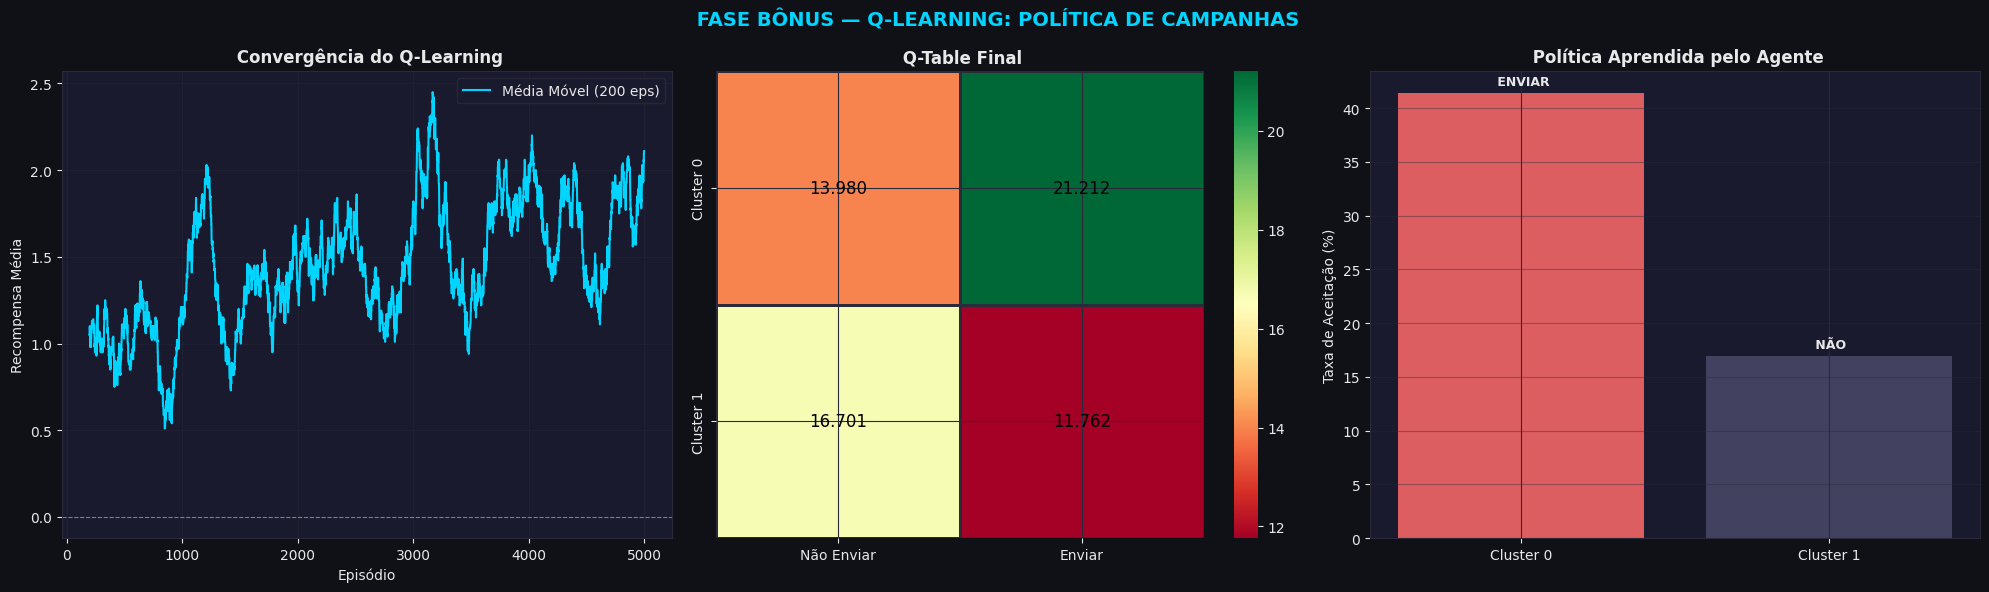

In [ ]:
#  Visualização Q-Learning
roll = pd.Series(rewards_hist).rolling(200).mean()

fig4, axes4 = plt.subplots(1, 3, figsize=(20, 6))
fig4.patch.set_facecolor('#0f1117')
CL5 = ['#00d4ff','#ff6b6b','#ffd166','#06d6a0','#a29bfe']

# Convergência
ax = axes4[0]; ax.set_facecolor('#1a1a2e')
ax.plot(roll, color='#00d4ff', linewidth=1.5, label='Média Móvel (200 eps)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Episódio', color='#e8e8e8'); ax.set_ylabel('Recompensa Média', color='#e8e8e8')
ax.set_title(' Convergência do Q-Learning', color='#e8e8e8', fontweight='bold')
ax.legend(facecolor='#1a1a2e', edgecolor='#2a2a3a', labelcolor='#e8e8e8')
ax.grid(color='#2a2a3a', alpha=0.4)
for s in ax.spines.values(): s.set_edgecolor('#2a2a3a')

# Q-Table heatmap
ax = axes4[1]; ax.set_facecolor('#1a1a2e')
sns.heatmap(Q, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            linewidths=1, linecolor='#2a2a3a',
            annot_kws={'size':12,'color':'black'},
            xticklabels=['Não Enviar','Enviar'],
            yticklabels=[f'Cluster {i}' for i in range(env.n_states)])
ax.set_title(' Q-Table Final', color='#e8e8e8', fontweight='bold')
for t in ax.get_xticklabels()+ax.get_yticklabels(): t.set_color('#e8e8e8')

# Política aprendida
ax = axes4[2]; ax.set_facecolor('#1a1a2e')
pols = [np.argmax(Q[cl]) for cl in range(env.n_states)]
accs = [env.labels[np.where(env.clusters==cl)[0]].mean() for cl in range(env.n_states)]
bar_colors = ['#ff6b6b' if p==1 else '#4a4a6a' for p in pols]
bars = ax.bar([f'Cluster {i}' for i in range(env.n_states)],
              [a*100 for a in accs], color=bar_colors, edgecolor='none', alpha=0.85)
for b,cl,pol in zip(bars, range(env.n_states), pols):
    lbl = ' ENVIAR' if pol==1 else ' NÃO'
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            lbl, ha='center', va='bottom', color='#e8e8e8', fontsize=9, fontweight='bold')
ax.set_ylabel('Taxa de Aceitação (%)', color='#e8e8e8')
ax.set_title(' Política Aprendida pelo Agente', color='#e8e8e8', fontweight='bold')
ax.grid(color='#2a2a3a', alpha=0.4, axis='y')
for s in ax.spines.values(): s.set_edgecolor('#2a2a3a')

fig4.suptitle(' FASE BÔNUS — Q-LEARNING: POLÍTICA DE CAMPANHAS',
              color='#00d4ff', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


<a id='8'></a>
## 8. Resumo Final


In [ ]:
# Tabela de resumo consolidada
print('=' * 65)
print('RESUMO FINAL — MARKETING CAMPAIGN MACHINE LEARNING')
print('=' * 65)

print('\n QUALIDADE DOS DADOS')
print(f'  Registros originais  : {df.shape[0]:,}')
print(f'  Após limpeza         : {df_proc.shape[0]:,}')
print(f'  Features criadas     : {len(feature_cols)}')
print(f'  Target (1=Aceitou)   : {df_proc["AcceptedCampaign"].mean()*100:.1f}% da base')

print('\n FASE 1 — SUPERVISIONADA')
for _, row in resultados.iterrows():
    print(f'  {row["Modelo"]:<32} F1={row["F1-Score"]:.3f} | AUC={row["AUC-ROC"]:.3f}')

print('\n FASE 2 — NÃO SUPERVISIONADA')
print(f'  Algoritmo KMeans           : Silhouette = {s_km:.4f}')
print(f'  Algoritmo Agglomerative    : Silhouette = {s_agg:.4f}')
print(f'  Número de clusters (K)     : {N_CLUSTERS}')

print('\n FASE BÔNUS — Q-LEARNING')
for cl in range(env.n_states):
    pol = 'ENVIAR' if np.argmax(Q[cl])==1 else 'NÃO ENVIAR'
    idx = np.where(env.clusters==cl)[0]
    print(f'  Cluster {cl}: {pol:<12} (acc_real={env.labels[idx].mean():.2f})')

print('\n RECOMENDAÇÕES PARA PRÓXIMAS ETAPAS')
recs = [
    '1. Aplicar SMOTE para balancear classes e melhorar Recall',
    '2. Explorar interações: Income × TotalSpending como feature',
    '3. Testar K=4 clusters para segmentação mais granular',
    '4. Evoluir Q-Learning para DQN com estado contínuo',
    '5. Usar SHAP values para interpretabilidade do XGBoost',
]
for r in recs: print(f'  {r}')
print('=' * 65)


RESUMO FINAL — MARKETING CAMPAIGN MACHINE LEARNING

 QUALIDADE DOS DADOS
  Registros originais  : 2,240
  Após limpeza         : 2,212
  Features criadas     : 14
  Target (1=Aceitou)   : 27.3% da base

 FASE 1 — SUPERVISIONADA
  Random Forest + GridSearch       F1=0.586 | AUC=0.801
  Gradient Boosting                F1=0.502 | AUC=0.807
  XGBoost                          F1=0.602 | AUC=0.809

 FASE 2 — NÃO SUPERVISIONADA
  Algoritmo KMeans           : Silhouette = 0.3483
  Algoritmo Agglomerative    : Silhouette = 0.2677
  Número de clusters (K)     : 2

 FASE BÔNUS — Q-LEARNING
  Cluster 0: ENVIAR       (acc_real=0.41)
  Cluster 1: NÃO ENVIAR   (acc_real=0.17)

 RECOMENDAÇÕES PARA PRÓXIMAS ETAPAS
  1. Aplicar SMOTE para balancear classes e melhorar Recall
  2. Explorar interações: Income × TotalSpending como feature
  3. Testar K=4 clusters para segmentação mais granular
  4. Evoluir Q-Learning para DQN com estado contínuo
  5. Usar SHAP values para interpretabilidade do XGBoost
